# Curva de demanda e validação temporal — Minerva

Este notebook seleciona a especificação mais simples capaz de prever volume em quilogramas
de forma estável dentro do suporte observado de preço e calendário. A análise é autocontida:
usa a base processada de desenvolvimento, o enunciado do desafio e as referências
bibliográficas listadas ao final.

A seleção utiliza somente observações até 31/10/2025. O holdout é carregado apenas depois que
família, calendário, coeficientes, correção de retransfomação, suporte e cenários de incerteza
são congelados em arquivos JSON.

## 1. Contrato de seleção

**Pergunta:** qual especificação prevê volume em kg com estabilidade suficiente para alimentar
a otimização de preços?

A comparação será feita em três rodadas:

1. **Calendário:** `P0`, `P1`, `P2` e `P3`, todos como curvas de potência com elasticidade
   compartilhada.
2. **Forma funcional:** potência, exponencial e linear usando o calendário vencedor.
3. **Tendência:** inclusão opcional do índice temporal no campeão das duas primeiras rodadas.

A validação começa com 55 observações e prevê, uma a uma, as 21 observações seguintes. Em
cada origem, o modelo e o fator de smearing são recalculados usando exclusivamente o passado.
Não há embaralhamento.

**Critérios pré-definidos:** WMAPE em kg é a métrica primária; RMSE, viés agregado e WMAPE
semanal são complementares. Modelos com inclinação de preço não negativa ou previsão não
positiva são inválidos. Entre candidatos válidos a até 1 ponto percentual do menor WMAPE,
será preferido o mais simples quando RMSE e WMAPE semanal não excederem em mais de 5% os
melhores valores da rodada.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

DATA_PATH = ROOT / 'data/processed/minerva_modelagem_treino.csv'
HOLDOUT_PATH = ROOT / 'data/interim/minerva_holdout.csv'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports/figures'
TABLES_DIR = ROOT / 'reports/tables'
PROCESSED_DIR = ROOT / 'data/processed'
for directory in [MODELS_DIR, FIGURES_DIR, TABLES_DIR, PROCESSED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CHAMPION_PATH = MODELS_DIR / 'demand_curve_champion.json'
UNCERTAINTY_PATH = MODELS_DIR / 'demand_curve_uncertainty.json'
SELECTION_PATH = MODELS_DIR / 'model_selection_summary.json'

ORDEM_DIAS = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
SEMENTE = 42
JANELA_INICIAL = 55
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 40)


def arquivo_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(1024 * 1024), b''):
            digest.update(bloco)
    return digest.hexdigest()


def salvar_json(payload, path):
    Path(path).write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )


def carregar_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def nucleo_modelo(artifact):
    chaves = [
        'artifact_version', 'model_id', 'family', 'calendar',
        'feature_order', 'coefficients', 'smearing_factor', 'price_support',
    ]
    return {chave: artifact[chave] for chave in chaves}


def hash_nucleo(artifact):
    serializado = json.dumps(
        nucleo_modelo(artifact),
        ensure_ascii=False,
        sort_keys=True,
        separators=(',', ':'),
    ).encode('utf-8')
    return hashlib.sha256(serializado).hexdigest()


def prever_artefato(
    artifact_or_path, preco, dia_semana, scenario='central',
    uncertainty_or_path=None, allow_extrapolation=False,
):
    artifact = (
        carregar_json(artifact_or_path)
        if isinstance(artifact_or_path, (str, Path))
        else artifact_or_path
    )
    contexto = artifact['calendar']['mapping'][dia_semana]
    suporte = artifact['price_support'][contexto]
    if not allow_extrapolation and not suporte['min'] <= preco <= suporte['max']:
        raise ValueError(
            f'Preço {preco:.2f} fora do suporte de {contexto}: '
            f'[{suporte["min"]:.2f}, {suporte["max"]:.2f}].'
        )
    feature = np.log(preco) if artifact['family'] == 'power' else preco / 100
    valores = {nome: 0.0 for nome in artifact['feature_order']}
    valores['const'] = 1.0
    valores['ln_preco' if artifact['family'] == 'power' else 'preco_100'] = feature
    if contexto != artifact['calendar']['baseline']:
        valores[f'contexto_{contexto}'] = 1.0
    linear = sum(
        artifact['coefficients'][nome] * valores[nome]
        for nome in artifact['feature_order']
    )
    volume = (
        np.exp(linear) * artifact['smearing_factor']
        if artifact['family'] in {'power', 'exponential'}
        else linear
    )
    if scenario != 'central':
        uncertainty = (
            carregar_json(uncertainty_or_path)
            if isinstance(uncertainty_or_path, (str, Path))
            else uncertainty_or_path
        )
        volume *= uncertainty['scenario_multipliers'][scenario]
    if volume <= 0:
        raise ValueError('A curva produziu volume não positivo.')
    return float(volume)

## 2. Carregamento exclusivo do desenvolvimento

A seleção deve começar pela base processada pelo EDA, sem acessar o holdout. A célula abaixo
valida esquema, datas, positividade e ordenação. Preço e volume precisam ser positivos porque
as curvas de potência e exponencial utilizam logaritmo da resposta ou do preço.

In [2]:
dados = pd.read_csv(DATA_PATH, parse_dates=['data', 'inicio_semana'])
colunas_obrigatorias = {
    'data', 'volume_kg', 'preco_kg', 'dia_semana', 'fim_semana',
    'indice_tempo', 'inicio_semana',
}
faltantes = colunas_obrigatorias - set(dados.columns)
if faltantes:
    raise ValueError(f'Colunas obrigatórias ausentes: {sorted(faltantes)}')
dados = dados.sort_values('data').reset_index(drop=True)
if dados['data'].duplicated().any():
    raise ValueError('Há datas duplicadas no desenvolvimento.')
if dados[list(['volume_kg', 'preco_kg'])].isna().any().any():
    raise ValueError('Volume ou preço contém valor ausente.')
if (dados[['volume_kg', 'preco_kg']] <= 0).any().any():
    raise ValueError('Volume e preço devem ser positivos.')

auditoria_desenvolvimento = pd.DataFrame({
    'Indicador': [
        'Observações', 'Data inicial', 'Data final', 'Observações iniciais de ajuste',
        'Previsões temporais', 'Semanas na validação',
    ],
    'Resultado': [
        len(dados), dados['data'].min().date(), dados['data'].max().date(),
        JANELA_INICIAL, len(dados) - JANELA_INICIAL,
        dados.iloc[JANELA_INICIAL:]['inicio_semana'].nunique(),
    ],
})
display(auditoria_desenvolvimento)

,Indicador,Resultado
0,Observações,76
1,Data inicial,2025-08-01
2,Data final,2025-10-31
3,Observações iniciais de ajuste,55
4,Previsões temporais,21
5,Semanas na validação,4


**Resultado do carregamento.** A base contém 76 observações entre 01/08/2025 e 31/10/2025.
As primeiras 55 formam a janela inicial; as 21 restantes, de 09/10 a 31/10, são previstas em
sequência e pertencem a quatro agregações semanais. O esquema e as condições de positividade
foram satisfeitos. Nenhuma informação do holdout foi carregada nesta etapa.

## 3. Candidatos e funções de validação

As cinco representações de calendário mantêm uma única inclinação de preço:

- `P0`: nenhum ajuste de calendário;
- `P1`: dia útil versus fim de semana;
- `P2`: um nível para cada dia da semana;
- `P3`: segunda a quinta, sexta e fim de semana.
- `P4`: segunda, terça a quinta, sexta e fim de semana.

`P3` e `P4` representam as duas distinções que precisam ser avaliadas. `P3` mantém segunda a
quinta no mesmo nível; `P4` separa segunda-feira e agrupa terça a quinta. Em ambas, sexta recebe
nível próprio e sábado e domingo compartilham o contexto de menor suporte. A decisão entre as
duas será refeita pelo mesmo protocolo temporal. Nenhuma especificação utiliza interação entre
preço e calendário.

A seguir são definidas funções para construir matrizes fixas, ajustar OLS, recalcular smearing,
prever uma observação futura e calcular métricas em kg. As mesmas funções serão usadas em todas
as rodadas para manter comparabilidade.

In [3]:
MAPAS_CONTEXTO = {
    'none': {dia: 'Geral' for dia in ORDEM_DIAS},
    'weekend': {
        dia: ('Fim_de_semana' if dia in ['Sábado', 'Domingo'] else 'Dia_util')
        for dia in ORDEM_DIAS
    },
    'weekday': {dia: dia for dia in ORDEM_DIAS},
    'grouped': {
        dia: (
            'Segunda_a_Quinta' if dia in ORDEM_DIAS[:4]
            else 'Sexta' if dia == 'Sexta'
            else 'Fim_de_semana'
        )
        for dia in ORDEM_DIAS
    },
    'grouped4': {
        dia: (
            'Segunda' if dia == 'Segunda'
            else 'Terca_a_Quinta' if dia in ORDEM_DIAS[1:4]
            else 'Sexta' if dia == 'Sexta'
            else 'Fim_de_semana'
        )
        for dia in ORDEM_DIAS
    },
}
ORDEM_CONTEXTO = {
    'none': ['Geral'],
    'weekend': ['Dia_util', 'Fim_de_semana'],
    'weekday': ORDEM_DIAS,
    'grouped': ['Segunda_a_Quinta', 'Sexta', 'Fim_de_semana'],
    'grouped4': ['Terca_a_Quinta', 'Segunda', 'Sexta', 'Fim_de_semana'],
}

CANDIDATOS_CALENDARIO = {
    'P0': {'family': 'power', 'calendar': 'none', 'trend': False},
    'P1': {'family': 'power', 'calendar': 'weekend', 'trend': False},
    'P2': {'family': 'power', 'calendar': 'weekday', 'trend': False},
    'P3': {'family': 'power', 'calendar': 'grouped', 'trend': False},
    'P4': {'family': 'power', 'calendar': 'grouped4', 'trend': False},
}


def matriz_desenho(base, family, calendar, trend=False):
    if family == 'power':
        preco = np.log(base['preco_kg']).rename('ln_preco')
    else:
        preco = (base['preco_kg'] / 100).rename('preco_100')
    matriz = pd.DataFrame({'const': 1.0, preco.name: preco}, index=base.index)
    contexto = base['dia_semana'].map(MAPAS_CONTEXTO[calendar])
    for nome in ORDEM_CONTEXTO[calendar][1:]:
        matriz[f'contexto_{nome}'] = (contexto == nome).astype(float)
    if trend:
        matriz['indice_tempo_10'] = base['indice_tempo'] / 10
    return matriz


def ajustar_candidato(base, specification, robust=False):
    family = specification['family']
    matriz = matriz_desenho(
        base, family, specification['calendar'], specification.get('trend', False)
    )
    resposta = (
        np.log(base['volume_kg'])
        if family in {'power', 'exponential'}
        else base['volume_kg']
    )
    modelo = sm.OLS(resposta, matriz).fit(cov_type='HC3' if robust else 'nonrobust')
    smearing = (
        float(np.exp(modelo.resid).mean())
        if family in {'power', 'exponential'}
        else 1.0
    )
    return modelo, smearing


def prever_candidato(modelo, smearing, nova_base, specification):
    family = specification['family']
    matriz = matriz_desenho(
        nova_base, family, specification['calendar'], specification.get('trend', False)
    )
    previsao = np.asarray(modelo.predict(matriz), dtype=float)
    if family in {'power', 'exponential'}:
        previsao = np.exp(previsao) * smearing
    return previsao


def validacao_expansiva(base, code, specification, initial=JANELA_INICIAL):
    registros = []
    for position in range(initial, len(base)):
        treino_janela = base.iloc[:position]
        observacao = base.iloc[[position]]
        modelo, smearing = ajustar_candidato(treino_janela, specification)
        previsao = float(
            prever_candidato(modelo, smearing, observacao, specification)[0]
        )
        registros.append({
            'candidate': code,
            'data': observacao['data'].iloc[0],
            'inicio_semana': observacao['inicio_semana'].iloc[0],
            'dia_semana': observacao['dia_semana'].iloc[0],
            'preco_kg': float(observacao['preco_kg'].iloc[0]),
            'volume_real_kg': float(observacao['volume_kg'].iloc[0]),
            'volume_previsto_kg': previsao,
            'price_slope': float(modelo.params.iloc[1]),
            'smearing': smearing,
            'training_rows': position,
        })
    previsoes = pd.DataFrame(registros)
    previsoes['erro_kg'] = previsoes['volume_previsto_kg'] - previsoes['volume_real_kg']
    previsoes['erro_absoluto_kg'] = previsoes['erro_kg'].abs()
    return previsoes


def metricas_validacao(previsoes, parameter_count):
    real = previsoes['volume_real_kg']
    previsto = previsoes['volume_previsto_kg']
    erro = previsto - real
    semanal = previsoes.groupby('inicio_semana')[
        ['volume_real_kg', 'volume_previsto_kg']
    ].sum()
    erro_semanal = semanal['volume_previsto_kg'] - semanal['volume_real_kg']
    return {
        'Parâmetros': int(parameter_count),
        'WMAPE': float(erro.abs().sum() / real.sum()),
        'RMSE': float(np.sqrt(np.mean(erro**2))),
        'Viés (kg)': float(erro.sum()),
        'Viés (%)': float(erro.sum() / real.sum()),
        'WMAPE semanal': float(erro_semanal.abs().sum() / semanal['volume_real_kg'].sum()),
        'Previsão mínima': float(previsto.min()),
        'Folds com inclinação não negativa': int((previsoes['price_slope'] >= 0).sum()),
    }


def comparar_candidatos(base, specifications):
    previsoes = {}
    linhas = []
    for code, specification in specifications.items():
        forecast = validacao_expansiva(base, code, specification)
        previsoes[code] = forecast
        parameter_count = matriz_desenho(base, **specification).shape[1]
        metrics = metricas_validacao(forecast, parameter_count)
        metrics['Código'] = code
        metrics['Válido'] = bool(
            metrics['Previsão mínima'] > 0
            and metrics['Folds com inclinação não negativa'] == 0
        )
        linhas.append(metrics)
    ranking = pd.DataFrame(linhas).set_index('Código').sort_values('WMAPE')
    return ranking, previsoes


def escolher_parcimonioso(ranking):
    validos = ranking.loc[ranking['Válido']].copy()
    melhor = validos.iloc[0]
    proximos = validos.loc[validos['WMAPE'] <= melhor['WMAPE'] + 0.01]
    proximos = proximos.loc[
        (proximos['RMSE'] <= melhor['RMSE'] * 1.05)
        & (proximos['WMAPE semanal'] <= melhor['WMAPE semanal'] * 1.05)
    ]
    return str(
        proximos.sort_values(['Parâmetros', 'WMAPE']).index[0]
    )


catalogo_candidatos = pd.DataFrame([
    ('P0', 'Potência', 'Sem calendário', 2),
    ('P1', 'Potência', 'Dia útil × fim de semana', 3),
    ('P2', 'Potência', 'Sete dias da semana', 8),
    ('P3', 'Potência', 'Segunda–quinta × sexta × fim de semana', 4),
    ('P4', 'Potência', 'Segunda × terça–quinta × sexta × fim de semana', 5),
], columns=['Código', 'Forma', 'Calendário', 'Parâmetros'])
display(catalogo_candidatos)

,Código,Forma,Calendário,Parâmetros
0,P0,Potência,Sem calendário,2
1,P1,Potência,Dia útil × fim de semana,3
2,P2,Potência,Sete dias da semana,8
3,P3,Potência,Segunda–quinta × sexta × fim de semana,4
4,P4,Potência,Segunda × terça–quinta × sexta × fim de semana,5


**Resultado da definição.** Os cinco candidatos diferem apenas na quantidade e na forma dos
interceptos de calendário. Todos usam uma elasticidade compartilhada, recalculam smearing em
cada janela e produzem métricas na escala operacional de quilogramas. `P3` usa quatro
parâmetros, `P4` usa cinco e `P2` usa oito. A comparação permite verificar se separar a
segunda-feira ou detalhar todos os dias melhora previsão o suficiente para justificar novos
parâmetros.

## 4. Regressão preço-volume solicitada pelo enunciado

O enunciado pede que a relação entre preço e volume seja estimada por regressão. A leitura mais
direta é uma regressão linear em escala original, `volume ~ preço`, sem calendário. Para evitar
que a comparação dependa de uma única escala, também é mostrado o baseline de potência sem
calendário, `ln(volume) ~ ln(preço)`.

Esses modelos respondem diretamente à solicitação mínima do documento, mas são avaliados pelo
mesmo esquema temporal usado nos modelos enriquecidos. R² e significância dentro da amostra
serão reportados como descrição, não como critério suficiente de escolha.

In [4]:
BASELINES_ENUNCIADO = {
    'D1-linear': {'family': 'linear', 'calendar': 'none', 'trend': False},
    'D2-potencia': {'family': 'power', 'calendar': 'none', 'trend': False},
}
ranking_documento, previsoes_documento = comparar_candidatos(
    dados, BASELINES_ENUNCIADO
)
ajustes_documento = []
for codigo, specification in BASELINES_ENUNCIADO.items():
    ajuste, _ = ajustar_candidato(dados, specification)
    ajustes_documento.append({
        'Código': codigo,
        'R² no desenvolvimento': float(ajuste.rsquared),
        'p-valor do modelo': float(ajuste.f_pvalue),
        'coeficiente de preço': float(ajuste.params.iloc[1]),
    })
ajustes_documento = pd.DataFrame(ajustes_documento).set_index('Código')
comparacao_documento = ranking_documento.join(ajustes_documento)
comparacao_documento.to_csv(TABLES_DIR / '02_baselines_enunciado.csv')

exibicao_documento = comparacao_documento.copy()
for coluna in ['WMAPE', 'Viés (%)', 'WMAPE semanal']:
    exibicao_documento[coluna] = 100 * exibicao_documento[coluna]
display(exibicao_documento.round(4))

,Parâmetros,WMAPE,RMSE,Viés (kg),Viés (%),WMAPE semanal,Previsão mínima,Folds com inclinação não negativa,Válido,R² no desenvolvimento,p-valor do modelo,coeficiente de preço
Código,,,,,,,,,,,,
D1-linear,2,73.0414,24.7268,-112.9187,-21.4549,27.4236,-2.5386,0,False,0.2208,0.0000,-22.6877
D2-potencia,2,78.0021,26.3764,-80.2951,-15.2563,30.2632,9.2953,0,True,0.0657,0.0255,-10.0333


**Resultado da regressão direta.** A regressão linear obteve WMAPE temporal de `73,04%`, RMSE
de `24,73 kg` e gerou previsão mínima de `-2,54 kg`; por isso, é operacionalmente inválida como
curva de demanda, mesmo sendo uma regressão simples conforme a leitura literal do enunciado.
O baseline de potência preservou positividade, mas apresentou WMAPE de `78,00%` e RMSE de
`26,38 kg`. Os dois confirmam associação negativa entre preço e volume, porém mostram que preço
sozinho não representa adequadamente as diferenças de nível da amostra.

## 5. Rodada de calendário

A primeira rodada mantém fixa a curva de potência e altera somente os níveis de calendário.
Isso evita misturar, em uma única comparação, decisões sobre forma funcional e segmentação.
Além da tabela global, o gráfico mostra o WMAPE de cada especificação nas mesmas 21 previsões.

,Parâmetros,WMAPE,RMSE,Viés (kg),Viés (%),WMAPE semanal,Previsão mínima,Folds com inclinação não negativa,Válido
Código,,,,,,,,,
P3,4,35.29,15.39,-110.83,-21.06,30.32,0.62,0,True
P4,5,38.16,16.14,-107.38,-20.40,32.04,0.61,0,True
P2,8,39.41,16.62,-107.42,-20.41,31.22,0.44,0,True
P1,3,53.51,21.14,-128.07,-24.33,30.38,0.69,0,True
P0,2,78.00,26.38,-80.30,-15.26,30.26,9.30,0,True


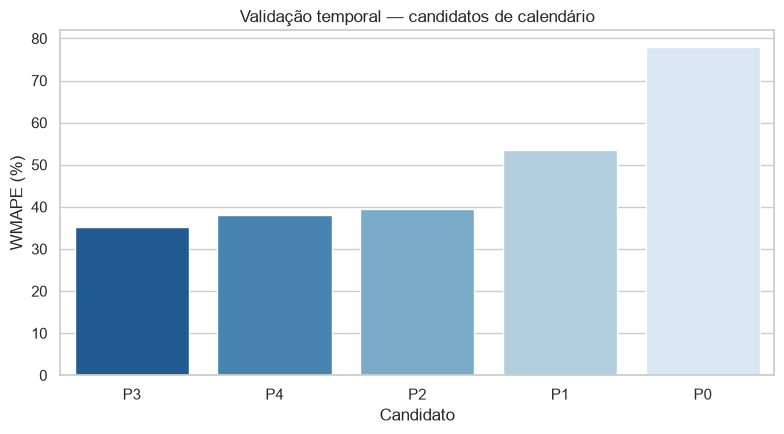

Calendário selecionado: P3


In [5]:
ranking_calendario, previsoes_calendario = comparar_candidatos(
    dados, CANDIDATOS_CALENDARIO
)
vencedor_calendario = escolher_parcimonioso(ranking_calendario)
ranking_calendario.to_csv(TABLES_DIR / '02_ranking_calendario.csv')

exibicao_calendario = ranking_calendario.copy()
for coluna in ['WMAPE', 'Viés (%)', 'WMAPE semanal']:
    exibicao_calendario[coluna] = 100 * exibicao_calendario[coluna]
display(exibicao_calendario.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
ordem = ranking_calendario.sort_values('WMAPE').index
sns.barplot(
    x=ordem,
    y=100 * ranking_calendario.loc[ordem, 'WMAPE'],
    hue=ordem,
    palette='Blues_r',
    legend=False,
    ax=ax,
)
ax.set(title='Validação temporal — candidatos de calendário', xlabel='Candidato', ylabel='WMAPE (%)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_ranking_calendario.png', dpi=160, bbox_inches='tight')
plt.show()
print(f'Calendário selecionado: {vencedor_calendario}')

**Resultado da rodada de calendário.** `P3` obteve o menor WMAPE (`35,29%`) e o menor RMSE
(`15,39 kg`). A distinção alternativa `P4`, que separa segunda-feira, apresentou WMAPE de
`38,16%`, RMSE de `16,14 kg` e WMAPE semanal de `32,04%`; portanto, o parâmetro adicional não
melhorou a validação. `P2`, embora mais detalhado, alcançou WMAPE de `39,41%` com oito
parâmetros. `P1` chegou a `53,51%` e `P0` a `78,00%`. Assim, a decisão é refeita em favor da
estrutura mais simples segunda–quinta / sexta / fim de semana.

## 6. Rodada de forma funcional

Mantendo o calendário de `P3`, serão comparadas:

- **potência:** `ln(volume) ~ ln(preço) + calendário`, com elasticidade constante;
- **exponencial:** `ln(volume) ~ preço + calendário`, com semielasticidade constante;
- **linear:** `volume ~ preço + calendário`.

As formas logarítmicas recebem smearing calculado dentro de cada janela. A forma linear será
rejeitada se produzir volume não positivo em qualquer previsão temporal.

In [6]:
CANDIDATOS_FORMA = {
    'P3': {'family': 'power', 'calendar': 'grouped', 'trend': False},
    'E1': {'family': 'exponential', 'calendar': 'grouped', 'trend': False},
    'L1': {'family': 'linear', 'calendar': 'grouped', 'trend': False},
}
ranking_forma, previsoes_forma = comparar_candidatos(dados, CANDIDATOS_FORMA)
vencedor_forma = escolher_parcimonioso(ranking_forma)
ranking_forma.to_csv(TABLES_DIR / '02_ranking_forma.csv')

exibicao_forma = ranking_forma.copy()
for coluna in ['WMAPE', 'Viés (%)', 'WMAPE semanal']:
    exibicao_forma[coluna] = 100 * exibicao_forma[coluna]
display(exibicao_forma.round(2))
print(f'Forma selecionada: {vencedor_forma}')

,Parâmetros,WMAPE,RMSE,Viés (kg),Viés (%),WMAPE semanal,Previsão mínima,Folds com inclinação não negativa,Válido
Código,,,,,,,,,
P3,4,35.29,15.39,-110.83,-21.06,30.32,0.62,0,True
E1,4,35.44,15.47,-113.49,-21.56,30.65,0.60,0,True
L1,4,55.02,19.08,-157.15,-29.86,29.86,-24.80,0,False


Forma selecionada: P3


**Resultado da rodada funcional.** Potência e exponencial tiveram desempenho praticamente
equivalente. A potência apresentou WMAPE de `35,29%`, ligeiramente inferior aos `35,44%` da
exponencial, e também obteve menor RMSE e WMAPE semanal. A forma linear alcançou WMAPE de
`55,02%` e gerou previsão mínima de `-24,80 kg`, violando a positividade operacional. A curva
de potência permanece campeã por desempenho, validade e interpretação direta da elasticidade.

## 7. Desafio opcional de tendência

A evolução cronológica mostrou que preço e volume mudam conjuntamente em outubro. Para testar
se uma tendência linear simples melhora previsão futura, o campeão é comparado com `P4`, que
adiciona `indice_tempo / 10`. A variável somente será mantida se superar o modelo sem tendência
segundo os mesmos critérios, pois ela pode absorver eventos não observados e degradar a
extrapolação para datas futuras.

In [7]:
CANDIDATOS_TENDENCIA = {
    'P3': {'family': 'power', 'calendar': 'grouped', 'trend': False},
    'T1': {'family': 'power', 'calendar': 'grouped', 'trend': True},
}
ranking_tendencia, previsoes_tendencia = comparar_candidatos(
    dados, CANDIDATOS_TENDENCIA
)
vencedor_tendencia = escolher_parcimonioso(ranking_tendencia)
ranking_tendencia.to_csv(TABLES_DIR / '02_ranking_tendencia.csv')

exibicao_tendencia = ranking_tendencia.copy()
for coluna in ['WMAPE', 'Viés (%)', 'WMAPE semanal']:
    exibicao_tendencia[coluna] = 100 * exibicao_tendencia[coluna]
display(exibicao_tendencia.round(2))
print(f'Especificação selecionada: {vencedor_tendencia}')

,Parâmetros,WMAPE,RMSE,Viés (kg),Viés (%),WMAPE semanal,Previsão mínima,Folds com inclinação não negativa,Válido
Código,,,,,,,,,
P3,4,35.29,15.39,-110.83,-21.06,30.32,0.62,0,True
T1,5,35.94,15.23,-103.20,-19.61,30.77,0.58,0,True


Especificação selecionada: P3


**Resultado do desafio de tendência.** `T1` reduziu discretamente o RMSE, de `15,39 kg` para
`15,23 kg`, mas piorou o WMAPE de `35,29%` para `35,94%` e o WMAPE semanal de `30,32%` para
`30,77%`. O ganho isolado em uma métrica secundária não compensa o parâmetro adicional nem o
risco de extrapolar uma tendência curta. A especificação congelada é `P3`: potência,
calendário agrupado e sem tendência.

## 8. Previsões temporais do campeão

Antes do ajuste em todos os 76 dias, é importante observar quando o modelo erra. O gráfico
compara volume realizado e previsão um passo à frente. A tabela semanal revela se erros diários
se acumulam ou se compensam, aspecto diretamente relacionado às metas de volume da otimização.

,volume_real_kg,volume_previsto_kg,erro_kg,erro_absoluto_percentual
inicio_semana,,,,
2025-10-06,86.21,59.09,-27.12,0.31
2025-10-13,296.06,192.36,-103.70,0.35
2025-10-20,79.29,103.66,24.37,0.31
2025-10-27,64.75,60.36,-4.39,0.07


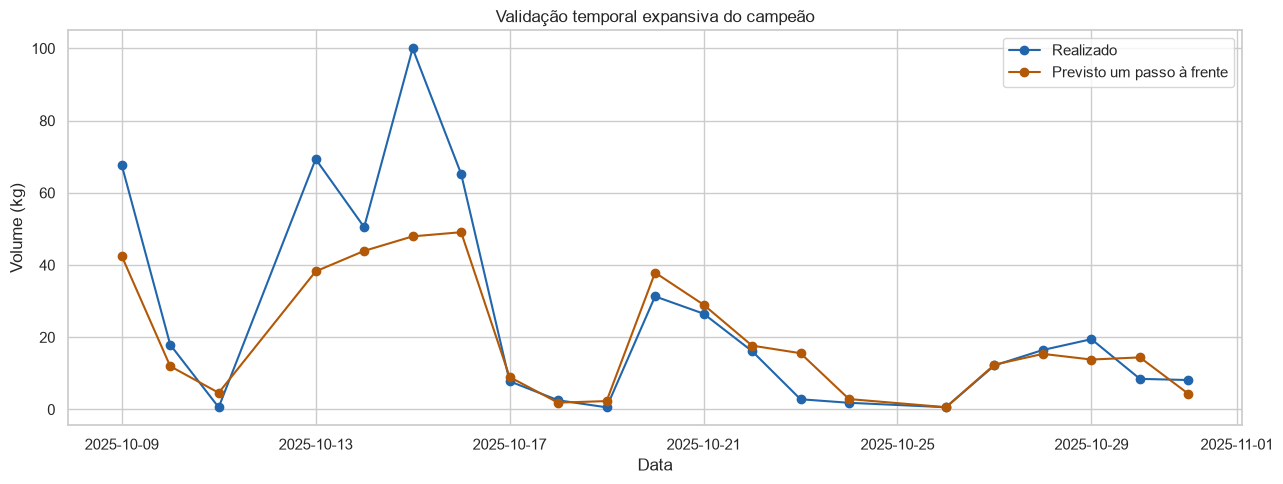

In [8]:
ESPECIFICACAO_CAMPEA = CANDIDATOS_CALENDARIO['P3']
previsoes_campea = previsoes_calendario['P3'].copy()
previsoes_campea.to_csv(
    TABLES_DIR / '02_previsoes_validacao_temporal.csv', index=False
)
metricas_internas = metricas_validacao(
    previsoes_campea,
    matriz_desenho(dados, **ESPECIFICACAO_CAMPEA).shape[1],
)
semanal_interno = previsoes_campea.groupby('inicio_semana')[[
    'volume_real_kg', 'volume_previsto_kg'
]].sum()
semanal_interno['erro_kg'] = (
    semanal_interno['volume_previsto_kg'] - semanal_interno['volume_real_kg']
)
semanal_interno['erro_absoluto_percentual'] = (
    semanal_interno['erro_kg'].abs() / semanal_interno['volume_real_kg']
)
display(semanal_interno.round(2))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    previsoes_campea['data'], previsoes_campea['volume_real_kg'],
    marker='o', label='Realizado', color='#2166ac'
)
ax.plot(
    previsoes_campea['data'], previsoes_campea['volume_previsto_kg'],
    marker='o', label='Previsto um passo à frente', color='#b35806'
)
ax.set(title='Validação temporal expansiva do campeão', xlabel='Data', ylabel='Volume (kg)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_validacao_temporal.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado temporal.** O modelo subestima o episódio de maior volume: o viés acumulado é
`-110,83 kg`, equivalente a `-21,06%` do volume validado. O maior erro semanal ocorre na semana
iniciada em 13/10, com subestimação de `103,70 kg`. Na semana iniciada em 27/10, o erro cai
para `4,39 kg`. O WMAPE de `35,29%` indica que o campeão é melhor que os concorrentes, mas não é
uma previsão de alta precisão; essa limitação precisa chegar aos cenários da otimização.

## 9. Ajuste final no desenvolvimento e interpretação

Com a especificação congelada, o modelo é ajustado nos 76 dias. A inferência usa matriz de
covariância HC3 porque ela é mais resistente à heterocedasticidade e a pontos de alta
alavancagem em amostras pequenas. O fator de smearing de Duan corrige a retransfomação de
`ln(volume)` para quilogramas.

In [9]:
modelo_final, smearing_final = ajustar_candidato(dados, ESPECIFICACAO_CAMPEA)
modelo_hc3 = modelo_final.get_robustcov_results(cov_type='HC3')
nomes_coeficientes = modelo_final.model.exog_names
tabela_coeficientes = pd.DataFrame({
    'coeficiente': modelo_final.params.to_numpy(),
    'erro_padrao_HC3': modelo_hc3.bse,
    'p_valor_HC3': modelo_hc3.pvalues,
    'IC95_inferior': modelo_hc3.conf_int()[:, 0],
    'IC95_superior': modelo_hc3.conf_int()[:, 1],
}, index=nomes_coeficientes)
tabela_coeficientes.index.name = 'variavel'
tabela_coeficientes.to_csv(TABLES_DIR / '02_coeficientes_campeao.csv')
display(tabela_coeficientes.round(4))
print(f'Smearing de Duan: {smearing_final:.6f}')
print(f'BIC no desenvolvimento: {modelo_final.bic:.3f}')

,coeficiente,erro_padrao_HC3,p_valor_HC3,IC95_inferior,IC95_superior
variavel,,,,,
const,91.5915,19.0853,0.0,53.5456,129.6373
ln_preco,-12.3647,2.6696,0.0,-17.6864,-7.0430
contexto_Sexta,-1.3394,0.1508,0.0,-1.6401,-1.0388
contexto_Fim_de_semana,-2.9670,0.2982,0.0,-3.5615,-2.3725


Smearing de Duan: 1.122597
BIC no desenvolvimento: 130.847


**Resultado do ajuste.** A equação estimada é:

`ln(volume) = 91,5915 - 12,3647 × ln(preço) - 1,3394 × I(sexta) - 2,9670 × I(fim de semana)`.

O fator de smearing é `1,1226`. Na curva de potência, o coeficiente de `ln(preço)` é a
elasticidade: dentro da faixa observada, aumento de 1% no preço está associado a redução média
de aproximadamente `12,36%` no volume, mantendo o contexto. O intervalo HC3 de 95% vai de
`-17,69` a `-7,04`, preservando o sinal negativo. A magnitude é elevada e deve ser interpretada
como resposta preditiva observacional, não como efeito causal definitivamente identificado.

## 10. Resíduos, heterocedasticidade e dependência temporal

Os resíduos são avaliados contra valores ajustados, preço, tempo e quantis normais. O teste de
Breusch–Pagan verifica mudança de variância; Durbin–Watson e Ljung–Box examinam dependência
serial. Esses diagnósticos não reabrem a seleção: servem para qualificar a incerteza e justificar
a inferência robusta.

,Diagnóstico,Resultado
0,Breusch-Pagan LM,10.1302
1,Breusch-Pagan p-valor,0.0175
2,Breusch-Pagan F,3.6910
3,Breusch-Pagan F p-valor,0.0157
4,Durbin-Watson,1.8282
5,Ljung-Box p-valor lag 1,0.5139
6,Ljung-Box p-valor lag 5,0.9428


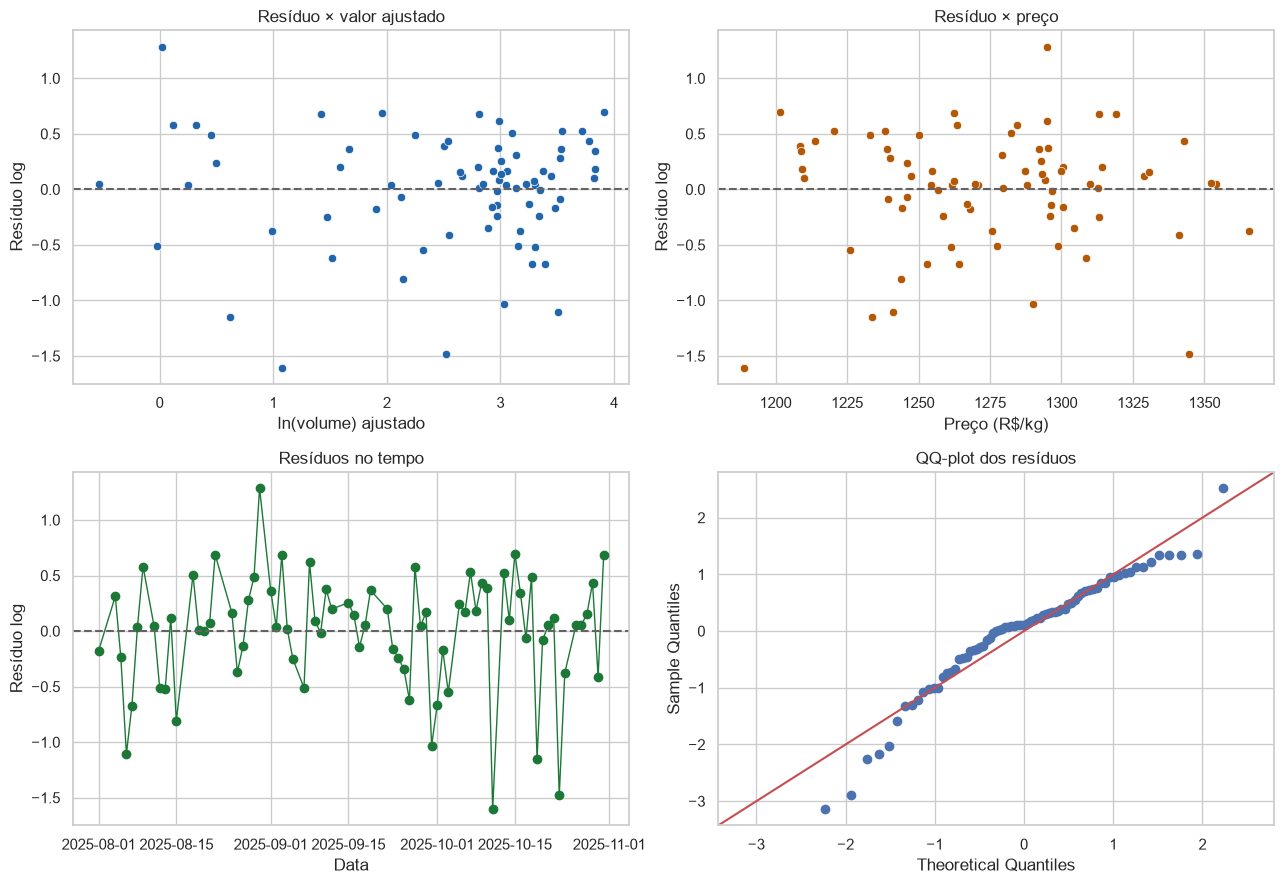

In [10]:
matriz_final = matriz_desenho(dados, **ESPECIFICACAO_CAMPEA)
ajustado_log = modelo_final.fittedvalues
residuos_log = modelo_final.resid
bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(residuos_log, matriz_final)
dw = float(durbin_watson(residuos_log))
ljung_box = acorr_ljungbox(residuos_log, lags=[1, 5], return_df=True)
diagnosticos_residuos = pd.DataFrame({
    'Diagnóstico': [
        'Breusch-Pagan LM', 'Breusch-Pagan p-valor', 'Breusch-Pagan F',
        'Breusch-Pagan F p-valor', 'Durbin-Watson',
        'Ljung-Box p-valor lag 1', 'Ljung-Box p-valor lag 5',
    ],
    'Resultado': [
        bp_lm, bp_p, bp_f, bp_f_p, dw,
        ljung_box.loc[1, 'lb_pvalue'], ljung_box.loc[5, 'lb_pvalue'],
    ],
})
diagnosticos_residuos.to_csv(
    TABLES_DIR / '02_diagnosticos_residuos.csv', index=False
)
display(diagnosticos_residuos.round(4))

fig, eixos = plt.subplots(2, 2, figsize=(13, 9))
sns.scatterplot(x=ajustado_log, y=residuos_log, ax=eixos[0, 0], color='#2166ac')
eixos[0, 0].axhline(0, color='#636363', linestyle='--')
eixos[0, 0].set(title='Resíduo × valor ajustado', xlabel='ln(volume) ajustado', ylabel='Resíduo log')
sns.scatterplot(x=dados['preco_kg'], y=residuos_log, ax=eixos[0, 1], color='#b35806')
eixos[0, 1].axhline(0, color='#636363', linestyle='--')
eixos[0, 1].set(title='Resíduo × preço', xlabel='Preço (R$/kg)', ylabel='Resíduo log')
eixos[1, 0].plot(dados['data'], residuos_log, marker='o', linewidth=1, color='#1b7837')
eixos[1, 0].axhline(0, color='#636363', linestyle='--')
eixos[1, 0].set(title='Resíduos no tempo', xlabel='Data', ylabel='Resíduo log')
sm.qqplot(residuos_log, line='45', fit=True, ax=eixos[1, 1])
eixos[1, 1].set_title('QQ-plot dos resíduos')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_diagnosticos_residuos.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado dos resíduos.** O Breusch–Pagan apresenta p-valor de `0,0175`, indicando variação
não constante dos resíduos e justificando os erros-padrão HC3. Durbin–Watson é `1,83`, próximo
de 2, e o Ljung–Box no lag 5 tem p-valor de `0,943`; não aparece evidência forte de
autocorrelação residual curta. O QQ-plot e a dispersão mostram desvios de cauda, reforçando que
intervalos baseados apenas em normalidade seriam otimistas.

## 11. Influência e estabilidade da elasticidade

Distância de Cook e alavancagem localizam observações capazes de alterar o ajuste. A análise
leave-one-out refaz o modelo 76 vezes, removendo uma observação por vez, e registra a
elasticidade resultante. Nenhum ponto é excluído: o objetivo é medir sensibilidade.

,data,dia_semana,volume_kg,preco_kg,cook,alavancagem,residuo_studentizado,elasticidade_sem_observacao,delta_elasticidade
57,2025-10-11,Sábado,0.5880,1188.8637,0.5232,0.1585,-3.5991,-14.0994,-1.7347
22,2025-08-30,Sábado,3.6837,1294.7879,0.1999,0.1063,2.7044,-12.7932,-0.4285
64,2025-10-19,Domingo,0.5880,1233.5666,0.1673,0.1106,-2.3947,-12.8649,-0.5002
68,2025-10-23,Quinta,2.8243,1344.6312,0.1304,0.0582,-3.0712,-11.1985,1.1662
11,2025-08-15,Sexta,3.7899,1243.8145,0.0558,0.0794,-1.6266,-12.6597,-0.2950
75,2025-10-31,Sexta,8.1470,1318.9196,0.0449,0.0887,1.3671,-12.7338,-0.3691
44,2025-09-27,Sábado,2.0046,1284.3068,0.0384,0.1024,1.1640,-12.4822,-0.1175
6,2025-08-09,Sábado,2.4589,1263.6254,0.0379,0.1002,1.1698,-12.3344,0.0303
16,2025-08-22,Sexta,14.1133,1262.2935,0.0362,0.0726,1.3689,-12.2707,0.0939
60,2025-10-15,Quarta,100.0000,1201.6317,0.0358,0.0701,1.3868,-11.7283,0.6364


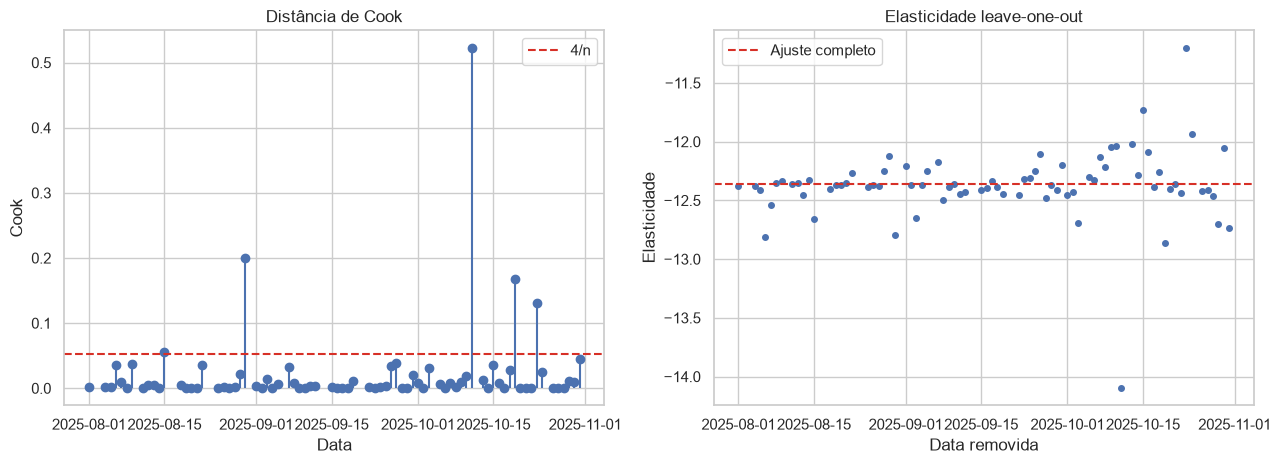

,Indicador,Resultado
0,Observações com Cook > 4/n,5.0000
1,Observações com alavancagem > 2p/n,7.0000
2,Elasticidade LOO mínima,-14.0994
3,Elasticidade LOO máxima,-11.1985
4,Maior variação absoluta da elasticidade,1.7347


In [11]:
influencia = modelo_final.get_influence()
tabela_influencia = pd.DataFrame({
    'data': dados['data'],
    'dia_semana': dados['dia_semana'],
    'volume_kg': dados['volume_kg'],
    'preco_kg': dados['preco_kg'],
    'cook': influencia.cooks_distance[0],
    'alavancagem': influencia.hat_matrix_diag,
    'residuo_studentizado': influencia.resid_studentized_external,
})
limite_cook = 4 / len(dados)
limite_alavancagem = 2 * matriz_final.shape[1] / len(dados)

elasticidades_loo = []
for indice in dados.index:
    modelo_loo, _ = ajustar_candidato(
        dados.drop(index=indice), ESPECIFICACAO_CAMPEA
    )
    elasticidades_loo.append(float(modelo_loo.params['ln_preco']))
tabela_influencia['elasticidade_sem_observacao'] = elasticidades_loo
tabela_influencia['delta_elasticidade'] = (
    tabela_influencia['elasticidade_sem_observacao']
    - modelo_final.params['ln_preco']
)
tabela_influencia.to_csv(TABLES_DIR / '02_influencia_leave_one_out.csv', index=False)
top_influencia = tabela_influencia.nlargest(10, 'cook').copy()
colunas_numericas_influencia = top_influencia.select_dtypes(include='number').columns
top_influencia[colunas_numericas_influencia] = top_influencia[
    colunas_numericas_influencia
].round(4)
display(top_influencia)

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))
eixos[0].stem(dados['data'], tabela_influencia['cook'], basefmt=' ')
eixos[0].axhline(limite_cook, color='#d73027', linestyle='--', label='4/n')
eixos[0].set(title='Distância de Cook', xlabel='Data', ylabel='Cook')
eixos[0].legend()
eixos[1].plot(
    dados['data'], tabela_influencia['elasticidade_sem_observacao'],
    marker='o', linestyle='', markersize=4
)
eixos[1].axhline(
    modelo_final.params['ln_preco'], color='#d73027', linestyle='--',
    label='Ajuste completo'
)
eixos[1].set(title='Elasticidade leave-one-out', xlabel='Data removida', ylabel='Elasticidade')
eixos[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_influencia.png', dpi=160, bbox_inches='tight')
plt.show()

resumo_influencia = pd.DataFrame({
    'Indicador': [
        'Observações com Cook > 4/n',
        'Observações com alavancagem > 2p/n',
        'Elasticidade LOO mínima', 'Elasticidade LOO máxima',
        'Maior variação absoluta da elasticidade',
    ],
    'Resultado': [
        int((tabela_influencia['cook'] > limite_cook).sum()),
        int((tabela_influencia['alavancagem'] > limite_alavancagem).sum()),
        min(elasticidades_loo), max(elasticidades_loo),
        tabela_influencia['delta_elasticidade'].abs().max(),
    ],
})
display(resumo_influencia.round(4))

**Resultado de influência.** Cinco observações superam a referência `4/n` para Cook e sete
superam `2p/n` para alavancagem. A observação de 11/10, com `0,59 kg` ao menor preço do suporte,
é a mais influente. Mesmo assim, a elasticidade leave-one-out permanece negativa em todas as
exclusões, variando de `-14,10` a `-11,20`. A maior alteração absoluta é `1,73`, relevante para
incerteza, mas insuficiente para inverter a conclusão sobre o sinal.

## 12. Robustez a perdas, fins de semana e colinearidade

Três verificações complementares são realizadas sem substituir o campeão:

1. regressão robusta de Huber, que reduz o peso de resíduos grandes;
2. ajuste apenas em dias úteis, para medir a influência das dez observações de fim de semana;
3. VIF dos preditores, para verificar colinearidade entre preço e calendário.

Como Huber e a exclusão de fins de semana não participaram da regra de seleção temporal, seus
resultados funcionam somente como análise de estabilidade.

In [12]:
resposta_log = np.log(dados['volume_kg'])
modelo_huber = sm.RLM(
    resposta_log, matriz_final, M=sm.robust.norms.HuberT()
).fit()
modelo_sem_fds, _ = ajustar_candidato(
    dados.loc[~dados['fim_semana']], ESPECIFICACAO_CAMPEA
)
comparacao_robustez = pd.DataFrame({
    'OLS': modelo_final.params,
    'Huber': modelo_huber.params,
    'OLS sem fim de semana': modelo_sem_fds.params,
})
display(comparacao_robustez.round(4))

vif = pd.DataFrame({
    'Variável': matriz_final.columns,
    'VIF': [
        variance_inflation_factor(matriz_final.to_numpy(), posicao)
        for posicao in range(matriz_final.shape[1])
    ],
})
vif.to_csv(TABLES_DIR / '02_vif.csv', index=False)
display(vif.round(3))

,OLS,Huber,OLS sem fim de semana
const,91.5915,102.5756,109.2304
ln_preco,-12.3647,-13.8943,-14.8312
contexto_Sexta,-1.3394,-1.3771,-1.3438
contexto_Fim_de_semana,-2.9670,-2.8578,0.0000


,Variável,VIF
0,const,55004.572
1,ln_preco,1.005
2,contexto_Sexta,1.036
3,contexto_Fim_de_semana,1.040


**Resultado de robustez.** A elasticidade é `-12,36` no OLS, `-13,89` no Huber e `-14,83`
quando os fins de semana são removidos. As três estimativas preservam sinal e ordem de
grandeza, embora a amplitude confirme sensibilidade. Os VIFs dos preditores ficam próximos de
1, indicando que preço e dummies de calendário não apresentam colinearidade problemática nesta
especificação. O VIF elevado da constante não é usado para diagnóstico.

## 13. Incerteza para a otimização

A otimização não deve receber apenas uma previsão pontual. Dois componentes de incerteza são
estimados exclusivamente com o desenvolvimento:

- quantis da razão `volume real / volume previsto` nas 21 previsões temporais, convertidos em
  multiplicadores conservador e otimista;
- bootstrap por blocos semanais, que preserva parcialmente a dependência dentro da semana e
  mede a variação da elasticidade.

O cenário central mantém a previsão com smearing. Os cenários conservador e otimista usam os
quantis 20% e 80%, evitando extremos pouco estáveis da pequena amostra.

In [13]:
razao_validacao = (
    previsoes_campea['volume_real_kg'] / previsoes_campea['volume_previsto_kg']
)
multiplicadores_cenario = {
    'conservative': float(razao_validacao.quantile(0.20)),
    'central': 1.0,
    'optimistic': float(razao_validacao.quantile(0.80)),
}

gerador = np.random.default_rng(SEMENTE)
semanas = dados['inicio_semana'].drop_duplicates().to_numpy()
elasticidades_bootstrap = []
for _ in range(1000):
    semanas_sorteadas = gerador.choice(semanas, size=len(semanas), replace=True)
    blocos = []
    for numero, semana in enumerate(semanas_sorteadas):
        bloco = dados.loc[dados['inicio_semana'] == semana].copy()
        bloco.index = np.arange(numero * 100, numero * 100 + len(bloco))
        blocos.append(bloco)
    amostra_bootstrap = pd.concat(blocos)
    modelo_bootstrap, _ = ajustar_candidato(
        amostra_bootstrap, ESPECIFICACAO_CAMPEA
    )
    elasticidades_bootstrap.append(float(modelo_bootstrap.params['ln_preco']))

quantis_bootstrap = np.quantile(elasticidades_bootstrap, [0.025, 0.5, 0.975])
tabela_incerteza = pd.DataFrame({
    'Indicador': [
        'Multiplicador conservador', 'Multiplicador central',
        'Multiplicador otimista', 'Elasticidade bootstrap 2,5%',
        'Elasticidade bootstrap mediana', 'Elasticidade bootstrap 97,5%',
        'Proporção de elasticidades não negativas',
    ],
    'Resultado': [
        multiplicadores_cenario['conservative'],
        multiplicadores_cenario['central'],
        multiplicadores_cenario['optimistic'],
        quantis_bootstrap[0], quantis_bootstrap[1], quantis_bootstrap[2],
        np.mean(np.asarray(elasticidades_bootstrap) >= 0),
    ],
})
display(tabela_incerteza.round(4))

,Indicador,Resultado
0,Multiplicador conservador,0.6413
1,Multiplicador central,1.0000
2,Multiplicador otimista,1.4979
3,"Elasticidade bootstrap 2,5%",-15.9844
4,Elasticidade bootstrap mediana,-12.3361
5,"Elasticidade bootstrap 97,5%",-6.7119
6,Proporção de elasticidades não negativas,0.0000


**Resultado da incerteza.** Os multiplicadores são `0,641` para o cenário conservador, `1,000`
para o central e `1,498` para o otimista. O intervalo bootstrap de 95% da elasticidade vai de
aproximadamente `-15,98` a `-6,71`, com mediana `-12,34`; nenhuma das 1.000 replicações gerou
elasticidade não negativa. O sinal é estável, mas a largura dos cenários mostra que o nível de
volume permanece incerto e deve ser considerado nas restrições semanais.

## 14. Suporte e curvas utilizáveis

Antes de congelar o modelo, é necessário registrar onde ele possui suporte. Cada contexto
recebe seus próprios limites mínimo e máximo de preço. O gráfico mostra a curva central somente
dentro dessas faixas; o otimizador deverá bloquear qualquer preço fora delas.

,n,min,max
contexto,,,
Segunda_a_Quinta,52,1201.63,1352.42
Sexta,14,1208.37,1365.49
Fim_de_semana,10,1188.86,1354.19


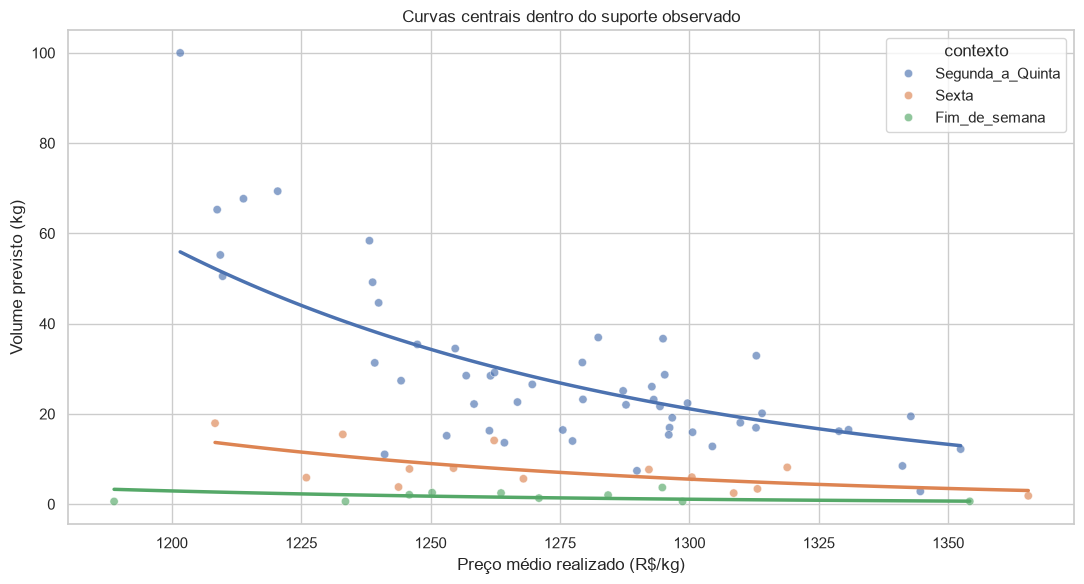

In [14]:
contexto_desenvolvimento = dados['dia_semana'].map(MAPAS_CONTEXTO['grouped'])
suporte_preco = (
    dados.assign(contexto=contexto_desenvolvimento)
    .groupby('contexto')
    .agg(n=('preco_kg', 'size'), min=('preco_kg', 'min'), max=('preco_kg', 'max'))
    .reindex(ORDEM_CONTEXTO['grouped'])
)
suporte_preco.to_csv(TABLES_DIR / '02_suporte_preco_contexto.csv')
display(suporte_preco.round(2))

dia_representativo = {
    'Segunda_a_Quinta': 'Segunda',
    'Sexta': 'Sexta',
    'Fim_de_semana': 'Sábado',
}
linhas_curva = []
for contexto, linha in suporte_preco.iterrows():
    grade = np.linspace(linha['min'], linha['max'], 100)
    nova_base = pd.DataFrame({
        'preco_kg': grade,
        'dia_semana': dia_representativo[contexto],
        'indice_tempo': 0,
    })
    previsto = prever_candidato(
        modelo_final, smearing_final, nova_base, ESPECIFICACAO_CAMPEA
    )
    linhas_curva.extend({
        'contexto': contexto, 'preco_kg': preco, 'volume_previsto_kg': volume
    } for preco, volume in zip(grade, previsto))
curvas = pd.DataFrame(linhas_curva)

ordem_contextos = ['Segunda_a_Quinta', 'Sexta', 'Fim_de_semana']
paleta_contextos = {
    'Segunda_a_Quinta': '#4c72b0',
    'Sexta': '#dd8452',
    'Fim_de_semana': '#55a868',
}
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=dados.assign(contexto=contexto_desenvolvimento),
    x='preco_kg', y='volume_kg', hue='contexto', hue_order=ordem_contextos,
    palette=paleta_contextos, alpha=0.65, ax=ax
)
sns.lineplot(
    data=curvas, x='preco_kg', y='volume_previsto_kg',
    hue='contexto', hue_order=ordem_contextos, palette=paleta_contextos,
    linewidth=2.5, legend=False, ax=ax
)
ax.set(
    title='Curvas centrais dentro do suporte observado',
    xlabel='Preço médio realizado (R$/kg)', ylabel='Volume previsto (kg)'
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_curvas_suporte.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado do suporte.** O contexto segunda–quinta possui 52 observações e preços entre
`R$ 1.201,63` e `R$ 1.352,42/kg`; sexta possui 14 observações entre `R$ 1.208,37` e
`R$ 1.365,49/kg`; fim de semana possui 10 observações entre `R$ 1.188,86` e `R$ 1.354,19/kg`.
A amplitude numérica do fim de semana não elimina sua baixa cobertura: recomendações nesse
contexto devem receber maior cautela, mesmo quando o preço estiver dentro do intervalo.

## 15. Congelamento antes do holdout

O artefato registra família, mapeamento de calendário, ordem das variáveis, coeficientes,
smearing, suporte, métricas temporais, diagnósticos, hashes e versões de pacotes. Um hash
separado é calculado apenas sobre o núcleo preditivo; assim, métricas do holdout podem ser
anexadas depois sem alterar a curva.

A célula também salva o resumo completo da seleção e o artefato de incerteza. Em seguida, a
função de produção reproduz previsões do ajuste em pontos internos ao suporte.

In [15]:
def registros_json(tabela):
    return json.loads(tabela.reset_index().to_json(orient='records', date_format='iso'))


suporte_json = {
    contexto: {
        'min': float(linha['min']),
        'max': float(linha['max']),
        'n': int(linha['n']),
    }
    for contexto, linha in suporte_preco.iterrows()
}
artifact = {
    'artifact_version': 2,
    'model_id': 'P3-power-grouped-calendar-v1',
    'family': 'power',
    'formula': (
        'ln(volume_kg) ~ ln(preco_kg) + '
        'I(sexta) + I(fim_de_semana)'
    ),
    'calendar': {
        'source_variable': 'dia_semana',
        'baseline': 'Segunda_a_Quinta',
        'contexts': ORDEM_CONTEXTO['grouped'],
        'mapping': MAPAS_CONTEXTO['grouped'],
    },
    'feature_order': list(modelo_final.params.index),
    'coefficients': {
        nome: float(valor) for nome, valor in modelo_final.params.items()
    },
    'smearing_factor': float(smearing_final),
    'price_support': suporte_json,
    'training': {
        'rows': int(len(dados)),
        'start': dados['data'].min().date().isoformat(),
        'end': dados['data'].max().date().isoformat(),
        'data_file': DATA_PATH.name,
        'data_sha256': arquivo_sha256(DATA_PATH),
    },
    'selection': {
        'method': 'expanding_window_one_step_ahead',
        'initial_training_rows': JANELA_INICIAL,
        'validation_rows': len(previsoes_campea),
        'validation_start': previsoes_campea['data'].min().date().isoformat(),
        'validation_end': previsoes_campea['data'].max().date().isoformat(),
        'metrics': {
            nome: (bool(valor) if isinstance(valor, (bool, np.bool_)) else float(valor))
            for nome, valor in metricas_internas.items()
        },
    },
    'inference': {
        'covariance': 'HC3',
        'coefficient_table': registros_json(tabela_coeficientes),
    },
    'diagnostics': {
        'breusch_pagan_p_value': float(bp_p),
        'durbin_watson': dw,
        'ljung_box_p_value_lag_5': float(ljung_box.loc[5, 'lb_pvalue']),
        'leave_one_out_elasticity_min': float(min(elasticidades_loo)),
        'leave_one_out_elasticity_max': float(max(elasticidades_loo)),
    },
    'holdout_evaluation': None,
    'observational_warning': (
        'Curva preditiva observacional; preço pode refletir demanda antecipada '
        'e variáveis omitidas. Não interpretar como efeito causal identificado.'
    ),
    'runtime': {
        'python': platform.python_version(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'statsmodels': sm.__version__,
        'prediction_module': None,
        'prediction_module_sha256': None,
    },
}
artifact['model_core_sha256'] = hash_nucleo(artifact)
frozen_core_hash = artifact['model_core_sha256']
salvar_json(artifact, CHAMPION_PATH)

uncertainty_artifact = {
    'artifact_version': 1,
    'model_core_sha256': frozen_core_hash,
    'source': 'expanding_window_prediction_ratios_and_weekly_block_bootstrap',
    'scenario_multipliers': multiplicadores_cenario,
    'bootstrap': {
        'seed': SEMENTE,
        'replications': 1000,
        'block': 'inicio_semana',
        'elasticity_quantiles': {
            'q025': float(quantis_bootstrap[0]),
            'q500': float(quantis_bootstrap[1]),
            'q975': float(quantis_bootstrap[2]),
        },
    },
    'warning': 'Fim de semana possui somente dez observações de desenvolvimento.',
}
salvar_json(uncertainty_artifact, UNCERTAINTY_PATH)

todas_previsoes = pd.concat([
    *previsoes_calendario.values(),
    previsoes_documento['D1-linear'],
    previsoes_forma['E1'], previsoes_forma['L1'],
    previsoes_tendencia['T1'],
], ignore_index=True)
todas_previsoes.to_csv(
    TABLES_DIR / '02_previsoes_todos_candidatos.csv', index=False
)
selection_summary = {
    'selection_rules': {
        'primary_metric': 'WMAPE',
        'near_best_absolute_wmape': 0.01,
        'secondary_metric_tolerance': 0.05,
        'invalid_if_nonpositive_prediction': True,
        'invalid_if_nonnegative_price_slope': True,
    },
    'calendar_round': registros_json(ranking_calendario),
    'document_baselines': registros_json(comparacao_documento),
    'functional_round': registros_json(ranking_forma),
    'trend_round': registros_json(ranking_tendencia),
    'champion': artifact['model_id'],
    'model_core_sha256': frozen_core_hash,
}
salvar_json(selection_summary, SELECTION_PATH)

artifact_carregado = carregar_json(CHAMPION_PATH)
verificacoes_reproducao = []
for contexto, linha in suporte_preco.iterrows():
    preco_teste = float((linha['min'] + linha['max']) / 2)
    dia = dia_representativo[contexto]
    nova_linha = pd.DataFrame({
        'preco_kg': [preco_teste], 'dia_semana': [dia], 'indice_tempo': [0]
    })
    previsao_notebook = float(prever_candidato(
        modelo_final, smearing_final, nova_linha, ESPECIFICACAO_CAMPEA
    )[0])
    previsao_artefato = prever_artefato(
        artifact_carregado, preco_teste, dia
    )
    verificacoes_reproducao.append({
        'contexto': contexto,
        'preco_teste': preco_teste,
        'previsao_notebook': previsao_notebook,
        'previsao_artefato': previsao_artefato,
        'diferenca': previsao_artefato - previsao_notebook,
    })
verificacoes_reproducao = pd.DataFrame(verificacoes_reproducao)
display(verificacoes_reproducao.round(10))
print(f'Núcleo congelado: {frozen_core_hash}')

,contexto,preco_teste,previsao_notebook,previsao_artefato,diferenca
0,Segunda_a_Quinta,1277.027409,26.343317,26.343317,0.0
1,Sexta,1286.929825,6.273067,6.273067,-0.0
2,Fim_de_semana,1271.525423,1.429885,1.429885,-0.0


Núcleo congelado: 761745984255a92f0745b74dabf6f228072650ee4bc89faf1f398bf3a371d5c5


**Resultado do congelamento.** Os três artefatos foram gravados antes da leitura do holdout.
O hash do núcleo preditivo é exibido acima. Para os três contextos, a função definida no
próprio notebook reproduziu as previsões do ajuste com diferença numérica nula. A curva também
bloqueia por padrão preços fora do suporte registrado. O script de inferência será produzido
somente depois do encerramento da análise, como entrega final desta fase.

## 16. Avaliação única no holdout oficial

Com o núcleo congelado, o holdout pode ser carregado. Preço e calendário são reconstruídos sem
reestimar coeficientes ou smearing. Cada previsão é produzida pelo artefato salvo; se algum preço
estiver fora do suporte do contexto, a execução será interrompida.

O resultado será apenas reportado. Ele não altera família, calendário, parâmetros, suporte ou
cenários de incerteza.

,data,volume_real_kg,preco_kg,numero_dia_semana,dia_semana,inicio_semana,contexto,volume_previsto_kg,erro_kg,erro_absoluto_kg
0,2025-11-03,29.907,1343.797,0,Segunda,2025-11-03,Segunda_a_Quinta,14.028,-15.879,15.879
1,2025-11-04,9.467,1294.317,1,Terça,2025-11-03,Segunda_a_Quinta,22.308,12.841,12.841
2,2025-11-05,16.435,1311.529,2,Quarta,2025-11-03,Segunda_a_Quinta,18.946,2.511,2.511
3,2025-11-06,17.256,1334.935,3,Quinta,2025-11-03,Segunda_a_Quinta,15.224,-2.032,2.032
4,2025-11-07,1.176,1327.982,4,Sexta,2025-11-03,Sexta,4.255,3.079,3.079
5,2025-11-10,18.186,1334.797,0,Segunda,2025-11-10,Segunda_a_Quinta,15.243,-2.942,2.942
6,2025-11-11,27.573,1302.994,1,Terça,2025-11-10,Segunda_a_Quinta,20.539,-7.034,7.034
7,2025-11-12,21.367,1311.074,2,Quarta,2025-11-10,Segunda_a_Quinta,19.027,-2.339,2.339
8,2025-11-13,32.469,1318.274,3,Quinta,2025-11-10,Segunda_a_Quinta,17.782,-14.688,14.688
9,2025-11-14,9.793,1282.923,4,Sexta,2025-11-10,Sexta,6.520,-3.274,3.274


,WMAPE,RMSE,Viés (kg),Viés (%),WMAPE semanal
0,0.3628,8.5263,-29.7574,-0.1621,0.1677


,volume_real_kg,volume_previsto_kg,erro_kg,erro_absoluto_percentual
inicio_semana,,,,
2025-11-03,74.241,74.760,0.520,0.007
2025-11-10,109.388,79.111,-30.277,0.277


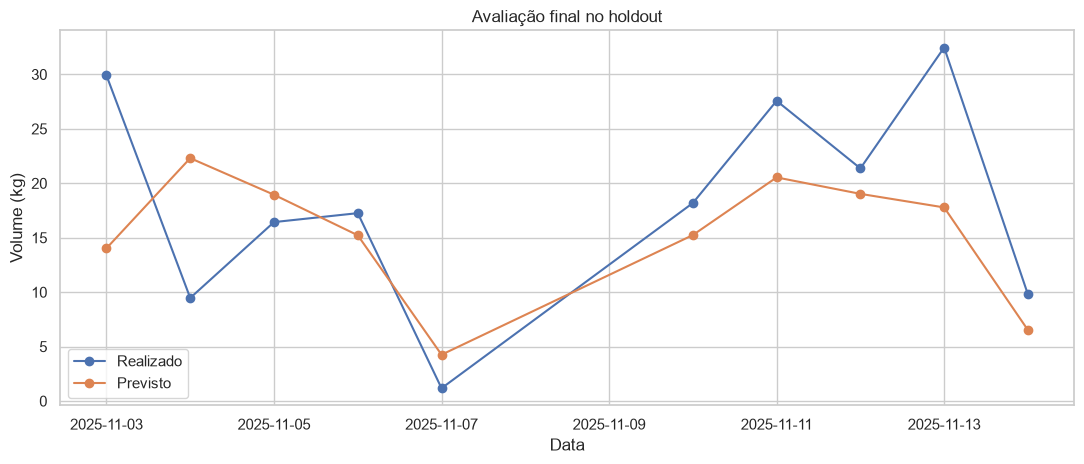

In [16]:
holdout_raw = pd.read_csv(HOLDOUT_PATH, parse_dates=['Data']).sort_values('Data')
holdout = pd.DataFrame({
    'data': holdout_raw['Data'],
    'volume_real_kg': holdout_raw['Volume Realizado (kg)'].astype(float),
    'preco_kg': (
        holdout_raw['Receita Realizada (R$)']
        / holdout_raw['Volume Realizado (kg)']
    ),
}).reset_index(drop=True)
holdout['numero_dia_semana'] = holdout['data'].dt.dayofweek
holdout['dia_semana'] = holdout['numero_dia_semana'].map(dict(enumerate(ORDEM_DIAS)))
holdout['inicio_semana'] = (
    holdout['data']
    - pd.to_timedelta(holdout['numero_dia_semana'], unit='D')
)
holdout['contexto'] = holdout['dia_semana'].map(MAPAS_CONTEXTO['grouped'])
holdout['volume_previsto_kg'] = [
    prever_artefato(CHAMPION_PATH, preco, dia)
    for preco, dia in zip(holdout['preco_kg'], holdout['dia_semana'])
]
holdout['erro_kg'] = holdout['volume_previsto_kg'] - holdout['volume_real_kg']
holdout['erro_absoluto_kg'] = holdout['erro_kg'].abs()

semanal_holdout = holdout.groupby('inicio_semana')[[
    'volume_real_kg', 'volume_previsto_kg'
]].sum()
semanal_holdout['erro_kg'] = (
    semanal_holdout['volume_previsto_kg'] - semanal_holdout['volume_real_kg']
)
semanal_holdout['erro_absoluto_percentual'] = (
    semanal_holdout['erro_kg'].abs() / semanal_holdout['volume_real_kg']
)
metricas_holdout = {
    'WMAPE': float(holdout['erro_absoluto_kg'].sum() / holdout['volume_real_kg'].sum()),
    'RMSE': float(np.sqrt(np.mean(holdout['erro_kg'] ** 2))),
    'Viés (kg)': float(holdout['erro_kg'].sum()),
    'Viés (%)': float(holdout['erro_kg'].sum() / holdout['volume_real_kg'].sum()),
    'WMAPE semanal': float(
        semanal_holdout['erro_kg'].abs().sum()
        / semanal_holdout['volume_real_kg'].sum()
    ),
}
exibicao_holdout = holdout.copy()
colunas_numericas_holdout = exibicao_holdout.select_dtypes(include='number').columns
exibicao_holdout[colunas_numericas_holdout] = exibicao_holdout[
    colunas_numericas_holdout
].round(3)
display(exibicao_holdout)
display(pd.DataFrame([metricas_holdout]).round(4))
display(semanal_holdout.round(3))

holdout.to_csv(PROCESSED_DIR / 'minerva_previsoes_holdout.csv', index=False)
holdout.to_csv(TABLES_DIR / '02_previsoes_holdout.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(holdout['data'], holdout['volume_real_kg'], marker='o', label='Realizado')
ax.plot(holdout['data'], holdout['volume_previsto_kg'], marker='o', label='Previsto')
ax.set(title='Avaliação final no holdout', xlabel='Data', ylabel='Volume (kg)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_holdout.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado do holdout.** Os dez preços pertencem ao suporte dos respectivos contextos. O
WMAPE foi `36,28%`, o RMSE `8,53 kg` e o viés acumulado `-29,76 kg` (`-16,21%`), mantendo o
padrão de subestimação observado na validação temporal. Na primeira semana, o volume total
previsto difere apenas `0,52 kg` do realizado; na segunda, o modelo subestima `30,28 kg`. O
WMAPE semanal agregado é `16,77%`. Como o holdout contém apenas segunda a sexta, ele não avalia
o comportamento de fim de semana.

## 17. Artefato final e tabela para a otimização

As métricas do holdout são anexadas somente como metadados. Antes e depois dessa atualização,
o hash do núcleo deve ser idêntico. Em seguida é criada uma tabela que transforma preço e dia
da semana em volumes conservador, central e otimista dentro do suporte permitido.

In [17]:
artifact_final = carregar_json(CHAMPION_PATH)
assert hash_nucleo(artifact_final) == frozen_core_hash
artifact_final['holdout_evaluation'] = {
    'rows': int(len(holdout)),
    'start': holdout['data'].min().date().isoformat(),
    'end': holdout['data'].max().date().isoformat(),
    'contains_weekend': bool(
        holdout['dia_semana'].isin(['Sábado', 'Domingo']).any()
    ),
    'metrics': {nome: float(valor) for nome, valor in metricas_holdout.items()},
    'predictions_file': 'data/processed/minerva_previsoes_holdout.csv',
    'frozen_model_core_sha256': frozen_core_hash,
}
salvar_json(artifact_final, CHAMPION_PATH)
assert hash_nucleo(carregar_json(CHAMPION_PATH)) == frozen_core_hash

linhas_cenario = []
for dia in ORDEM_DIAS:
    contexto = MAPAS_CONTEXTO['grouped'][dia]
    suporte = suporte_json[contexto]
    for preco in np.linspace(suporte['min'], suporte['max'], 21):
        linhas_cenario.append({
            'dia_semana': dia,
            'contexto': contexto,
            'preco_kg': preco,
            'volume_conservador_kg': prever_artefato(
                CHAMPION_PATH, preco, dia, scenario='conservative',
                uncertainty_or_path=UNCERTAINTY_PATH
            ),
            'volume_central_kg': prever_artefato(
                CHAMPION_PATH, preco, dia
            ),
            'volume_otimista_kg': prever_artefato(
                CHAMPION_PATH, preco, dia, scenario='optimistic',
                uncertainty_or_path=UNCERTAINTY_PATH
            ),
        })
tabela_cenarios = pd.DataFrame(linhas_cenario)
tabela_cenarios.to_csv(
    TABLES_DIR / '02_tabela_preco_volume_cenarios.csv', index=False
)

reproducao_holdout = np.array([
    prever_artefato(CHAMPION_PATH, preco, dia)
    for preco, dia in zip(holdout['preco_kg'], holdout['dia_semana'])
])
assert np.allclose(reproducao_holdout, holdout['volume_previsto_kg'])
assert (tabela_cenarios['volume_conservador_kg'] > 0).all()
assert (tabela_cenarios['volume_central_kg'] > 0).all()
assert (tabela_cenarios['volume_otimista_kg'] > 0).all()

display(tabela_cenarios.groupby('contexto').agg(
    linhas=('preco_kg', 'size'),
    preco_min=('preco_kg', 'min'),
    preco_max=('preco_kg', 'max'),
    volume_central_min=('volume_central_kg', 'min'),
    volume_central_max=('volume_central_kg', 'max'),
).round(3))
print(f'Hash preservado após o holdout: {frozen_core_hash}')

,linhas,preco_min,preco_max,volume_central_min,volume_central_max
contexto,,,,,
Fim_de_semana,42,1188.864,1354.187,0.656,3.283
Segunda_a_Quinta,84,1201.632,1352.423,12.961,55.906
Sexta,21,1208.368,1365.491,3.015,13.669


Hash preservado após o holdout: 761745984255a92f0745b74dabf6f228072650ee4bc89faf1f398bf3a371d5c5


**Resultado dos artefatos.** O hash permaneceu inalterado após a avaliação final, confirmando
que somente metadados foram acrescentados. A função de produção reproduziu todas as previsões
do holdout e gerou volumes positivos nos três cenários. O arquivo de cenários contém 21 preços
por dia da semana, sempre limitados ao suporte do contexto correspondente.

## 18. Conclusões da modelagem

1. O calendário é necessário: a curva sem contexto apresentou WMAPE de 78%, enquanto a
   codificação agrupada reduziu a métrica para 35,29%.
2. O agrupamento segunda–quinta / sexta / fim de semana superou tanto a distinção que separa
   segunda-feira quanto a codificação completa dos sete dias, usando menos parâmetros.
3. Potência e exponencial foram próximas; potência venceu por pequena vantagem preditiva,
   positividade e interpretação direta da elasticidade.
4. A tendência linear não melhorou a métrica primária e foi descartada.
5. A elasticidade estimada é negativa e estável em sinal, mas elevada em magnitude e sensível
   à amostra; ela representa associação preditiva observacional.
6. Heterocedasticidade e observações influentes justificam HC3, smearing e cenários amplos.
7. O holdout confirmou erro semelhante ao da validação interna e viés de subestimação; ele não
   contém fins de semana.
8. A curva está pronta para a otimização somente dentro do suporte registrado e acompanhada dos
   cenários conservador, central e otimista.

A limitação principal permanece a identificação causal. O preço pode ter sido definido em
resposta à demanda antecipada, e variáveis como estoque, promoção, concorrência e clima não
estão disponíveis. O modelo deve ser usado para planejamento sob incerteza, não como medida
definitiva do efeito causal de uma alteração de preço.

## 19. Produto de inferência

Somente após a seleção, os diagnósticos, o congelamento e a avaliação final, o código estável de
inferência é promovido para `src/modeling/demand_curve.py`. Esse módulo não estima nem escolhe
modelos: ele apenas carrega o artefato, verifica sua integridade, aplica calendário e cenários,
bloqueia extrapolação e retorna volume em quilogramas.

In [18]:
import contextlib
import io

with contextlib.redirect_stderr(io.StringIO()):
    from src.modeling.demand_curve import (
        file_sha256 as product_file_sha256,
        load_artifact as product_load_artifact,
        model_core_sha256 as product_core_sha256,
        predict_volume_from_artifact as product_predict_volume,
        save_artifact as product_save_artifact,
    )

artifact_product = product_load_artifact(CHAMPION_PATH)
assert product_core_sha256(artifact_product) == frozen_core_hash
previsoes_produto = np.array([
    product_predict_volume(CHAMPION_PATH, preco, dia)
    for preco, dia in zip(holdout['preco_kg'], holdout['dia_semana'])
])
diferenca_maxima_produto = float(
    np.max(np.abs(previsoes_produto - holdout['volume_previsto_kg']))
)
assert diferenca_maxima_produto < 1e-10

artifact_product['runtime']['prediction_module'] = 'src/modeling/demand_curve.py'
artifact_product['runtime']['prediction_module_sha256'] = product_file_sha256(
    ROOT / 'src/modeling/demand_curve.py'
)
product_save_artifact(artifact_product, CHAMPION_PATH)
assert product_core_sha256(product_load_artifact(CHAMPION_PATH)) == frozen_core_hash

print(f'Diferença máxima entre notebook e produto: {diferenca_maxima_produto:.3e}')
print(
    'SHA-256 do módulo de inferência: '
    f'{artifact_product["runtime"]["prediction_module_sha256"]}'
)

Diferença máxima entre notebook e produto: 0.000e+00
SHA-256 do módulo de inferência: 7fcf0d93785cb8b76aed1848714c2a06fa8eedf70ec0e442f0945d4b278a177e


**Resultado do produto.** O módulo final reproduziu todas as previsões do holdout com diferença
inferior a `10⁻¹⁰`. O hash do script foi anexado aos metadados sem modificar o núcleo do modelo.
Assim, o Notebook 3 poderá consumir a curva sem reexecutar a seleção estatística.

## 20. Validação dos entregáveis

A última verificação confirma que o notebook produziu todos os arquivos contratados e que o
artefato bloqueia extrapolação. Ela não realiza novo ajuste nem modifica o modelo.

In [19]:
entregaveis = [
    CHAMPION_PATH,
    UNCERTAINTY_PATH,
    SELECTION_PATH,
    PROCESSED_DIR / 'minerva_previsoes_holdout.csv',
    TABLES_DIR / '02_previsoes_validacao_temporal.csv',
    TABLES_DIR / '02_tabela_preco_volume_cenarios.csv',
    FIGURES_DIR / '02_validacao_temporal.png',
    FIGURES_DIR / '02_diagnosticos_residuos.png',
    FIGURES_DIR / '02_influencia.png',
    FIGURES_DIR / '02_curvas_suporte.png',
    FIGURES_DIR / '02_holdout.png',
    ROOT / 'src/modeling/demand_curve.py',
]
ausentes = [str(path) for path in entregaveis if not path.exists()]
if ausentes:
    raise FileNotFoundError(f'Entregáveis ausentes: {ausentes}')

try:
    prever_artefato(CHAMPION_PATH, 2000.0, 'Segunda')
except ValueError as error:
    bloqueio_extrapolacao = 'fora do suporte' in str(error)
else:
    bloqueio_extrapolacao = False
assert bloqueio_extrapolacao

print('Notebook 2 concluído.')
print(f'Artefato campeão: {CHAMPION_PATH}')
print(f'Artefato de incerteza: {UNCERTAINTY_PATH}')
print(f'Resumo de seleção: {SELECTION_PATH}')
print('Extrapolação bloqueada com sucesso.')

Notebook 2 concluído.
Artefato campeão: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/demand_curve_champion.json
Artefato de incerteza: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/demand_curve_uncertainty.json
Resumo de seleção: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/models/model_selection_summary.json
Extrapolação bloqueada com sucesso.


**Resultado da validação.** Todos os artefatos, tabelas e gráficos foram encontrados. O núcleo
congelado reproduz as previsões documentadas, oferece cenários de incerteza e rejeita preços
fora do suporte. O contrato de entrada para o Notebook 3 está completo.

## 21. Referências

- MINERVA FOODS; UNIFESP; ITA. *Desafio de Otimização de Preços*. Documento disponível em
  `docs/referencias/Minerva_Unifesp_ITA.pdf`.
- PHILLIPS, Robert L. *Pricing and Revenue Optimization*. 2. ed. Documento disponível em
  `docs/referencias/dokumen.pub_pricing-and-revenue-optimization-second-edition-9781503614260.pdf`.
- MULLAPUDI, Pavan Nithin. *Pricing Optimization across Domains*. Documento disponível em
  `docs/referencias/IJERET-V6I3P103.pdf`.
- DUAN, Naihua. Smearing estimate: a nonparametric retransformation method. *Journal of the
  American Statistical Association*, 1983.